In [13]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
TRAIN_FILE = "./raw_data/data-1774627968260.csv"
VAL_FILE   = "./raw_data/data-1774610506409.csv"

CPU_MIN_THRESHOLD = 0
CPU_LIMIT         = 2.0    # ліміт пода при зборі (2000m) → cpu/CPU_LIMIT ∈ [0,1]
EPS               = 1e-6

# Фіксована архітектура
LAYER_SIZE    = 64
DROPOUT_RATE  = 0.35
L2_REG        = 1e-4
LEARNING_RATE = 1e-4
BATCH_SIZE    = 32
QUANTILE      = 0.75

# Cross-validation
N_SPLITS   = 3
MAX_EPOCHS = 150
PATIENCE   = 20

# ── Простір пошуку ────────────────────────────────────────────
WINDOW_SIZES      = [6, 8, 10, 15, 20]
FORECAST_HORIZONS = [12, 15, 18]   # / 60s / 75s / 90s — K8s-relevant only
FEATURE_MODES     = ['velocity', 'velocity+levels']

total_runs = len(WINDOW_SIZES) * len(FORECAST_HORIZONS) * len(FEATURE_MODES)
print(f"Комбінацій: {total_runs} × {N_SPLITS} folds = {total_runs * N_SPLITS} тренувань")


Комбінацій: 30 × 3 folds = 90 тренувань


In [15]:
def load_locust(path):
    df = pd.read_csv(path, parse_dates=['ts'])
    df = df.sort_values('ts').reset_index(drop=True)
    df = df.rename(columns={'input_cpu': 'cpu', 'input_ram': 'ram', 'input_rps': 'rps'})
    df = df[['cpu', 'rps']].dropna()
    df = df[df['cpu'] > CPU_MIN_THRESHOLD].reset_index(drop=True)
    df['cpu'] = df['cpu'] / CPU_LIMIT   # utilization [0, 1]
    return df

df_train = load_locust(TRAIN_FILE)
df_val   = load_locust(VAL_FILE)
print(f"Train: {len(df_train)} рядків")
print(f"Val:   {len(df_val)} рядків (held-out)")
print(f"CPU utilization range — train: [{df_train['cpu'].min():.3f}, {df_train['cpu'].max():.3f}]")


Train: 2022 рядків
Val:   553 рядків (held-out)
CPU utilization range — train: [0.001, 0.829]


In [16]:
import tensorflow.keras.backend as K

def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return K.mean(K.maximum(q * e, (q - 1) * e))
    loss.__name__ = f'quantile_loss_q{int(q*100)}'
    return loss


def transform_data(df, forecast_horizon, feature_mode):
    """
    Колонки виходу:
      velocity:        [cpu_step, rps_step,                       target]  (n=2)
      velocity+levels: [cpu_step, rps_step, cpu_level, rps_level, target]  (n=4)

    target = cpu_utilization через forecast_horizon кроків (point prediction) ∈ [0, 1]
    """
    out = pd.DataFrame()
    out['cpu_step'] = (df['cpu'] - df['cpu'].shift(1)) / (df['cpu'].shift(1) + EPS)
    out['rps_step'] = (df['rps'] - df['rps'].shift(1)) / (df['rps'].shift(1) + EPS)

    if feature_mode == 'velocity+levels':
        out['cpu_level'] = df['cpu'].values
        out['rps_level'] = np.log1p(df['rps'].values)

    # Таргет: point prediction — той самий що і у фінальному тренуванні
    out['target'] = df['cpu'].shift(-forecast_horizon)

    return out.dropna().values


def n_feat(feature_mode):
    if feature_mode == 'velocity':
        return 2
    elif feature_mode == 'velocity+levels':
        return 4
    else:
        raise ValueError(f"Unknown feature_mode: {feature_mode}")


def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size + 1):
        Xs.append(X[i : i + window_size])
        ys.append(y[i + window_size - 1])
    return np.array(Xs), np.array(ys)


def build_model(window_size, n_features):
    model = Sequential([
        Input(shape=(window_size, n_features)),
        GRU(
            LAYER_SIZE,
            kernel_regularizer=l2(L2_REG),
            recurrent_regularizer=l2(L2_REG),
        ),
        Dropout(DROPOUT_RATE),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=Adam(LEARNING_RATE, clipnorm=1.0),
        loss=quantile_loss(QUANTILE),
        metrics=['mae'],
    )
    return model


def make_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5),
    ]

print("Helpers defined.")


Helpers defined.


In [17]:
def cross_validate(df, window_size, forecast_horizon, feature_mode):
    """
    Walk-forward cross-validation (TimeSeriesSplit).
    Повертає (mean_val_loss, std_val_loss) по N_SPLITS фолдах.
    """
    raw = transform_data(df, forecast_horizon, feature_mode)
    nf  = n_feat(feature_mode)

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_losses = []

    for train_idx, val_idx in tscv.split(raw):
        raw_tr = raw[train_idx]
        raw_vl = raw[val_idx]

        min_rows = window_size + 5
        if len(raw_tr) < min_rows or len(raw_vl) < min_rows:
            continue

        scaler_X = StandardScaler()
        X_tr_sc = scaler_X.fit_transform(raw_tr[:, :nf])
        y_tr    = raw_tr[:, nf]   # utilization [0,1] — scaler_y не потрібен
        X_vl_sc = scaler_X.transform(raw_vl[:, :nf])
        y_vl    = raw_vl[:, nf]

        X_tr, y_tr = create_sequences(X_tr_sc, y_tr.reshape(-1, 1), window_size)
        X_vl, y_vl = create_sequences(X_vl_sc, y_vl.reshape(-1, 1), window_size)

        tf.random.set_seed(42)
        model = build_model(window_size, nf)
        model.fit(
            X_tr, y_tr,
            validation_data=(X_vl, y_vl),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=make_callbacks(),
            verbose=0,
        )

        best_val_loss = min(model.history.history['val_loss'])
        fold_losses.append(best_val_loss)

    if not fold_losses:
        return float('nan'), float('nan')
    return float(np.mean(fold_losses)), float(np.std(fold_losses))

print("cross_validate() defined.")


cross_validate() defined.


In [18]:
results = []
total = len(WINDOW_SIZES) * len(FORECAST_HORIZONS) * len(FEATURE_MODES)
i = 0

for ws in WINDOW_SIZES:
    for fh in FORECAST_HORIZONS:
        for fm in FEATURE_MODES:
            i += 1
            t0 = time.time()
            mean_loss, std_loss = cross_validate(df_train, ws, fh, fm)
            elapsed = time.time() - t0
            results.append({
                'window_size':      ws,
                'context_sec':      ws * 5,
                'forecast_horizon': fh,
                'horizon_sec':      fh * 5,
                'feature_mode':     fm,
                'mean_val_loss':    round(mean_loss, 4),
                'std_val_loss':     round(std_loss, 4),
            })
            print(f"[{i:2d}/{total}] ws={ws:2d}({ws*5:3d}s) fh={fh}({fh*5}s) {fm:15s} "
                  f"→ loss={mean_loss:.4f}±{std_loss:.4f}  ({elapsed:.0f}s)")

results_df = pd.DataFrame(results).sort_values('mean_val_loss').reset_index(drop=True)
print("\n── Топ-5 конфігурацій ──")
print(results_df[['window_size','horizon_sec','feature_mode','mean_val_loss','std_val_loss']].head(5).to_string(index=False))

[ 1/30] ws= 6( 30s) fh=12(60s) velocity        → loss=0.1083±0.0043  (31s)
[ 2/30] ws= 6( 30s) fh=12(60s) velocity+levels → loss=0.0965±0.0096  (32s)
[ 3/30] ws= 6( 30s) fh=15(75s) velocity        → loss=0.1079±0.0046  (28s)
[ 4/30] ws= 6( 30s) fh=15(75s) velocity+levels → loss=0.1008±0.0074  (34s)
[ 5/30] ws= 6( 30s) fh=18(90s) velocity        → loss=0.1098±0.0037  (28s)
[ 6/30] ws= 6( 30s) fh=18(90s) velocity+levels → loss=0.1044±0.0048  (36s)
[ 7/30] ws= 8( 40s) fh=12(60s) velocity        → loss=0.1042±0.0037  (47s)
[ 8/30] ws= 8( 40s) fh=12(60s) velocity+levels → loss=0.0966±0.0095  (27s)
[ 9/30] ws= 8( 40s) fh=15(75s) velocity        → loss=0.1065±0.0049  (28s)
[10/30] ws= 8( 40s) fh=15(75s) velocity+levels → loss=0.1018±0.0081  (31s)
[11/30] ws= 8( 40s) fh=18(90s) velocity        → loss=0.1087±0.0018  (47s)
[12/30] ws= 8( 40s) fh=18(90s) velocity+levels → loss=0.1065±0.0057  (31s)
[13/30] ws=10( 50s) fh=12(60s) velocity        → loss=0.1025±0.0062  (45s)
[14/30] ws=10( 50s) fh=12

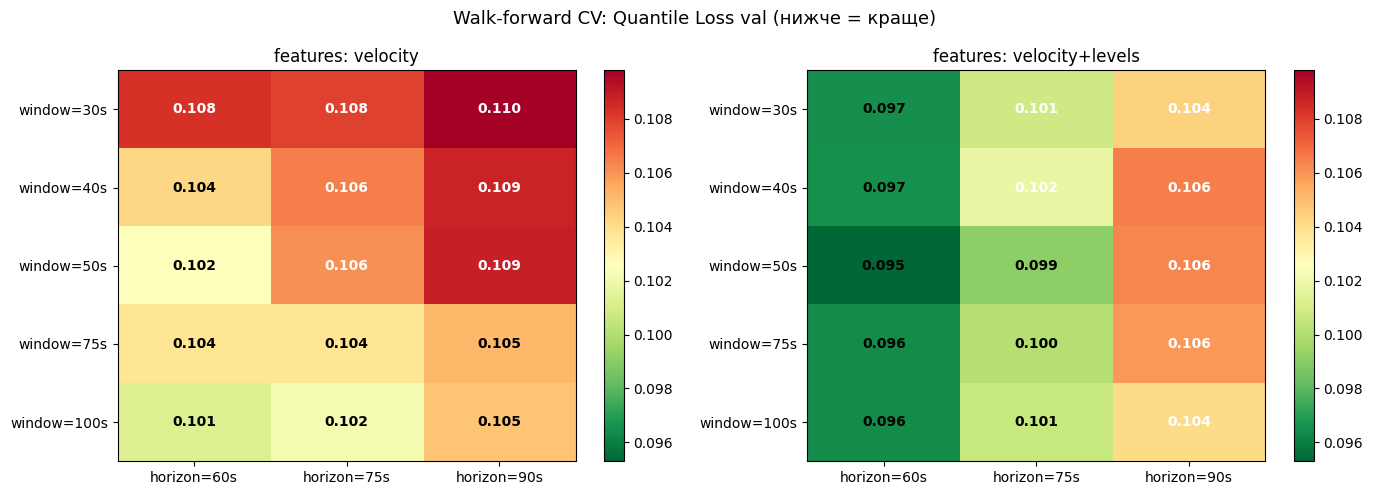

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Walk-forward CV: Quantile Loss val (нижче = краще)', fontsize=13)

for ax, fm in zip(axes, FEATURE_MODES):
    subset = results_df[results_df['feature_mode'] == fm]
    pivot  = subset.pivot(index='window_size', columns='forecast_horizon', values='mean_val_loss')

    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
                   vmin=results_df['mean_val_loss'].min(),
                   vmax=results_df['mean_val_loss'].max())

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'horizon={c*5}s' for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'window={r*5}s' for r in pivot.index])
    ax.set_title(f'features: {fm}')

    for r in range(len(pivot.index)):
        for c in range(len(pivot.columns)):
            val = pivot.values[r, c]
            ax.text(c, r, f'{val:.3f}', ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if val > pivot.values.mean() else 'black')

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('hyperparam_search.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── Фінальна оцінка найкращої конфігурації на held-out val ──
best = results_df.iloc[0]
print(f"Найкраща конфігурація:")
print(f"  window_size={best.window_size} ({best.context_sec}s)")
print(f"  forecast_horizon={best.forecast_horizon} ({best.horizon_sec}s)")
print(f"  feature_mode={best.feature_mode}")
print(f"  CV loss: {best.mean_val_loss:.4f} ± {best.std_val_loss:.4f}")

ws = int(best.window_size)
fh = int(best.forecast_horizon)
fm = best.feature_mode
nf = n_feat(fm)

raw_tr = transform_data(df_train, fh, fm)
raw_vl = transform_data(df_val,   fh, fm)

scaler_X = StandardScaler()
X_tr_sc = scaler_X.fit_transform(raw_tr[:, :nf])
y_tr    = raw_tr[:, nf]
X_vl_sc = scaler_X.transform(raw_vl[:, :nf])
y_vl    = raw_vl[:, nf]

X_tr, y_tr = create_sequences(X_tr_sc, y_tr.reshape(-1, 1), ws)
X_vl, y_vl = create_sequences(X_vl_sc, y_vl.reshape(-1, 1), ws)

tf.random.set_seed(42)
best_model = build_model(ws, nf)
history = best_model.fit(
    X_tr, y_tr,
    validation_data=(X_vl, y_vl),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1,
)
best_epoch = int(np.argmin(history.history['val_loss'])) + 1
print(f"\nBest epoch: {best_epoch}")


Найкраща конфігурація:
  window_size=10 (50s)
  forecast_horizon=12 (60s)
  feature_mode=velocity+levels
  CV loss: 0.0953 ± 0.0094
Epoch 1/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1124 - mae: 0.3231 - val_loss: 0.1113 - val_mae: 0.3488 - learning_rate: 1.0000e-04
Epoch 2/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1057 - mae: 0.3105 - val_loss: 0.1106 - val_mae: 0.3424 - learning_rate: 1.0000e-04
Epoch 3/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1020 - mae: 0.3040 - val_loss: 0.1106 - val_mae: 0.3383 - learning_rate: 1.0000e-04
Epoch 4/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0994 - mae: 0.2997 - val_loss: 0.1106 - val_mae: 0.3349 - learning_rate: 1.0000e-04
Epoch 5/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0984 - mae: 0.2966 - val_loss: 0.1106 - val_mae: 0.3324 - learning_rate: 1.0000e-04
Epoch 6/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0970 - mae: 0.2925 - val_loss: 0.1103 - val_mae: 0.3291 - learning_rate: 1.0000e-0

Метрики на held-out val (q=0.75, без safety factor):
  MAE:       613.4 m
  RMSE:      709.9 m
  Bias:      +384.4 m  (завищує)
  Underpred: 20.7%
  Pred util range: [0.150, 0.766]


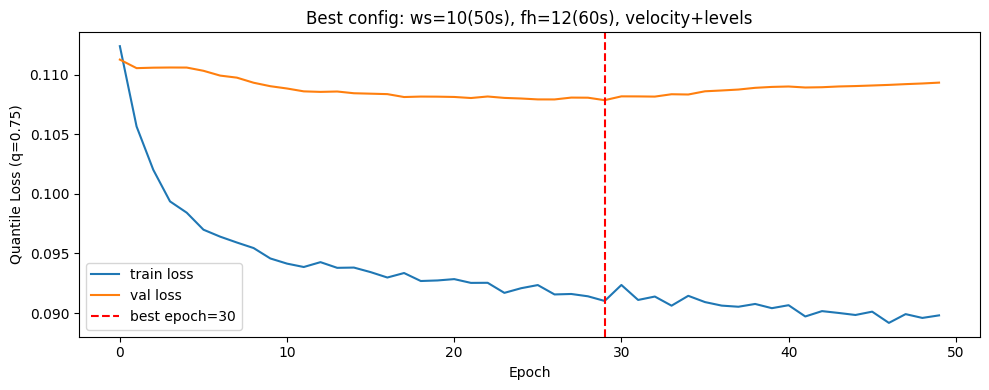

In [21]:
# Абсолютні метрики на held-out val
# Модель напряму предиктить utilization [0,1] → множимо на CPU_LIMIT для cores
X_eval_sc = scaler_X.transform(raw_vl[:, :nf])
y_eval    = raw_vl[:, nf]
X_eval, y_eval_seq = create_sequences(X_eval_sc, y_eval.reshape(-1, 1), ws)

y_pred_util = best_model.predict(X_eval, verbose=0).flatten()
y_true_util = y_eval_seq.flatten()

actual_peak_m = y_true_util * CPU_LIMIT * 1000
pred_peak_m   = y_pred_util * CPU_LIMIT * 1000

mae_m         = np.mean(np.abs(actual_peak_m - pred_peak_m))
rmse_m        = np.sqrt(np.mean((actual_peak_m - pred_peak_m) ** 2))
bias_m        = np.mean(pred_peak_m - actual_peak_m)
underpred_pct = np.mean(pred_peak_m < actual_peak_m) * 100

print(f"Метрики на held-out val (q={QUANTILE}, без safety factor):")
print(f"  MAE:       {mae_m:.1f} m")
print(f"  RMSE:      {rmse_m:.1f} m")
print(f"  Bias:      {bias_m:+.1f} m  ({'завищує' if bias_m > 0 else 'занижує'})")
print(f"  Underpred: {underpred_pct:.1f}%")
print(f"  Pred util range: [{y_pred_util.min():.3f}, {y_pred_util.max():.3f}]")

# Learning curves
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.axvline(best_epoch - 1, color='red', linestyle='--', label=f'best epoch={best_epoch}')
plt.xlabel('Epoch')
plt.ylabel(f'Quantile Loss (q={QUANTILE})')
plt.title(f'Best config: ws={ws}({ws*5}s), fh={fh}({fh*5}s), {fm}')
plt.legend()
plt.tight_layout()
plt.savefig('best_config_training.png', dpi=150, bbox_inches='tight')
plt.show()
